In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("Teachers rank.xlsx")

In [7]:
df.head()

,SL,Teacher Name,Dept,Task 1 (10),Task 2 (10),Task 3 (10),Task 4 (10),Task 5 (10),Total (50)
0,1,Adnan Shakur,English,8.9,9.5,9.0,8.0,10,45.4
1,2,Golam Saleh Ahmed Salem,EEE,9.6,9.5,9.5,6.0,10,44.6
2,3,Md. Mutassim Fuad,EEE,9.6,6.5,8.5,9.5,10,44.1
3,4,Rubieyat Bin Ali,CE,9.5,7.5,9.0,8.0,10,44.0
4,5,Asik Arefin,BBA,9.7,7.5,7.0,9.5,10,43.7


In [14]:
df.groupby("Dept").mean(numeric_only=True)

,SL,Task 1 (10),Task 2 (10),Task 3 (10),Task 4 (10),Task 5 (10),Total (50)
Dept,,,,,,,
BBA,27.300000,8.970000,6.750000,6.850000,6.000000,9.000000,37.570000
CE,24.200000,9.160000,6.300000,7.600000,5.900000,10.000000,38.660000
CSE,39.466667,7.960000,5.600000,5.266667,6.366667,9.333333,34.326667
EEE,29.625000,8.562500,5.937500,6.812500,5.875000,10.000000,37.187500
English,34.100000,8.620000,6.000000,5.700000,5.650000,10.000000,35.970000
GEd,46.285714,8.557143,4.857143,5.642857,6.142857,7.142857,31.914286
ME,29.800000,9.100000,5.800000,6.700000,5.700000,10.000000,37.300000
MPH,53.000000,6.900000,3.500000,3.500000,8.000000,10.000000,31.900000


Text(0.5, 1.0, 'Average Total (50) by Department')

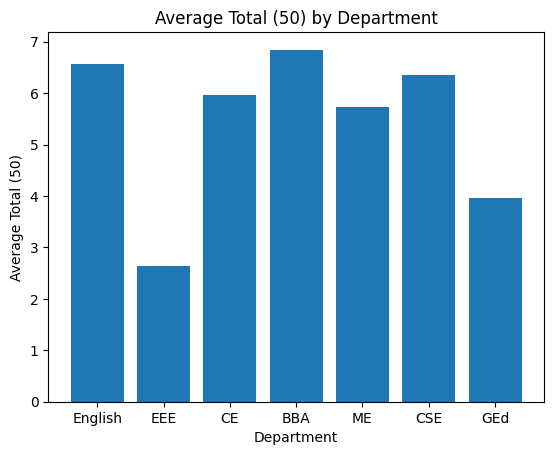

In [26]:
dept = df['Dept'].unique()
average = df.groupby("Dept").std(numeric_only=True)['Total (50)'].values

plt.bar(dept, average)
plt.xlabel('Department')
plt.ylabel('Average Total (50)')
plt.title('Average Total (50) by Department')

In [32]:
df[df['Dept'] == 'EEE'][['Teacher Name', 'Total (50)']].sort_values(by='Total (50)', ascending=False)

,Teacher Name,Total (50)
1,Golam Saleh Ahmed Salem,44.6
2,Md. Mutassim Fuad,44.1
7,Noor Md Shahriar,42.3
24,Sourav Sarker,38.6
42,Sajal Somodder Roni,35.5
44,Saiful Islam,34.6
47,Al-Amin Howlader,33.9
62,Al Imran,23.9


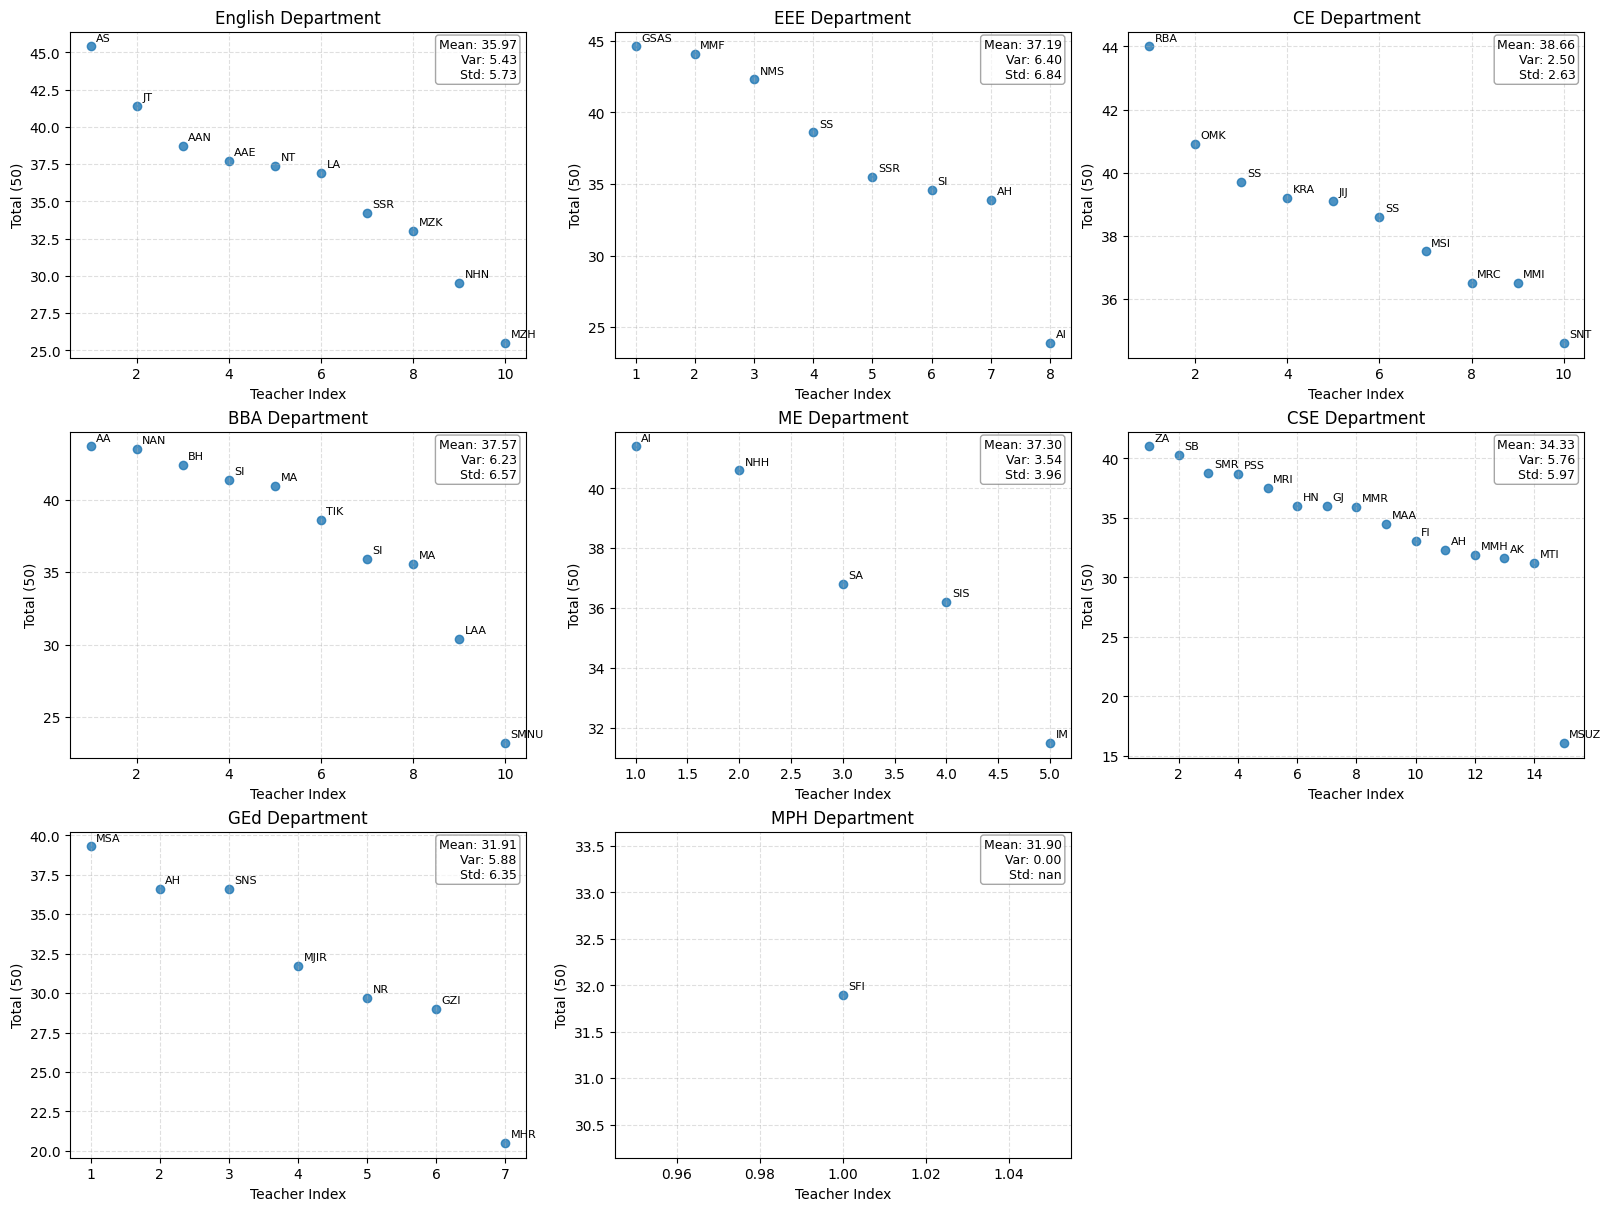

In [36]:
n_depts = len(dept)
n_cols = 3
n_rows = (n_depts + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), constrained_layout=True)
axes = axes.flat if n_depts > 1 else [axes]

def get_initials(name):
    parts = [p for p in str(name).replace(".", " ").split() if p]
    return "".join(p[0].upper() for p in parts)

for i, d in enumerate(dept):
    sub = df.loc[df["Dept"] == d, ["Teacher Name", "Total (50)"]].reset_index(drop=True)
    x = range(1, len(sub) + 1)
    y = sub["Total (50)"]

    axes[i].scatter(x, y, alpha=0.8)
    axes[i].set_title(f"{d} Department")
    axes[i].set_xlabel("Teacher Index")
    axes[i].set_ylabel("Total (50)")
    axes[i].grid(True, linestyle="--", alpha=0.4)

    # mean and variance in plot corner
    mean_val = y.mean()
    var_val = y.std(ddof=0)  # population variance
    std_val = y.std(ddof=1)  # sample standard deviation
    axes[i].text(
        0.98, 0.98,
        f"Mean: {mean_val:.2f}\nVar: {var_val:.2f}\nStd: {std_val:.2f}",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="gray")
    )

    for xi, yi, name in zip(x, y, sub["Teacher Name"]):
        axes[i].annotate(
            get_initials(name),
            (xi, yi),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8
        )

for j in range(i + 1, n_rows * n_cols):
    axes[j].axis("off")

plt.show()